In this session we will proceed through the Skip-Gram model to see how vectors are moved by prediction error in the embedding paradigm. The goals are

1. Build skip-gram pairs from a small corpus (window-based)
2. Train a tiny Skip-Gram with Negative Sampling in PyTorch
3. Watch:

  * loss decreases
  * selected word distances change
  * 2D geometry forms

## Modules

In [ ]:
from __future__ import annotations

import random
import re
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

## Tokenizers

Let's define simple tokenizers on our own just for the activity, instead of using the usual NLP pipelines

In [ ]:
def simple_tokenize(text: str) -> List[str]:
    """
    Lowercase, remove punctuation (keeps letters/apostrophes), split on spaces.
    """
    text = text.lower()
    text = re.sub(r"[^a-z'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return []
    return text.split()


def build_vocab(tokens: List[str], min_count: int = 1) -> Tuple[Dict[str, int], Dict[int, str]]:
    """
    Build word ↔ id maps.
    """
    counts: Dict[str, int] = {}
    for w in tokens:
        counts[w] = counts.get(w, 0) + 1

    vocab = []
    for w, c in counts.items():
        if c >= min_count:
            vocab.append(w)

    vocab = sorted(vocab)
    word2id = {w: i for i, w in enumerate(vocab)}
    id2word = {i: w for w, i in word2id.items()}
    return word2id, id2word


def make_skipgram_pairs(tokens: List[str], word2id: Dict[str, int], window: int = 2) -> List[Tuple[int, int]]:
    """
    Generate (center_id, context_id) pairs for a symmetric window.
    """
    ids = []
    for w in tokens:
        if w in word2id:
            ids.append(word2id[w])

    pairs: List[Tuple[int, int]] = []
    for i in range(len(ids)):
        center = ids[i]
        left = max(0, i - window)
        right = min(len(ids), i + window + 1)
        for j in range(left, right):
            if j == i:
                continue
            pairs.append((center, ids[j]))
    return pairs

# Skip-gram Model

The following is a minimal skip-gram + negative sampling model, which only aims at illustrate what goes on behind the curtains

In [ ]:
class SkipGramNS(nn.Module):
    """
    Minimal Skip-Gram with Negative Sampling.

    Two embedding tables:
    - in_emb:  center word vectors
    - out_emb: context word vectors
    """
    def __init__(self, vocab_size: int, dim: int):
        super().__init__()
        self.in_emb = nn.Embedding(vocab_size, dim)
        self.out_emb = nn.Embedding(vocab_size, dim)

        # small random init: start with no structure
        nn.init.normal_(self.in_emb.weight, mean=0.0, std=0.5)
        nn.init.normal_(self.out_emb.weight, mean=0.0, std=0.5)

    def loss_one(self, center_id: int, pos_context_id: int, neg_context_ids: List[int]) -> torch.Tensor:
        """
        Compute negative sampling loss for ONE training event:

        L = -log σ(v·u_pos) - Σ log σ(-v·u_neg)
        """
        center = torch.tensor([center_id], dtype=torch.long)
        pos = torch.tensor([pos_context_id], dtype=torch.long)
        neg = torch.tensor(neg_context_ids, dtype=torch.long)

        v = self.in_emb(center).squeeze(0)         # (d,)
        u_pos = self.out_emb(pos).squeeze(0)       # (d,)
        u_neg = self.out_emb(neg)                  # (K, d)

        pos_score = torch.dot(v, u_pos)            # scalar
        pos_term = F.logsigmoid(pos_score)         # log σ(v·u_pos)

        neg_scores = torch.mv(u_neg, v)            # (K,)
        neg_term = F.logsigmoid(-neg_scores).sum() # Σ log σ(-v·u_neg)

        return -(pos_term + neg_term)

def sample_negatives(vocab_size: int, k: int, avoid: int) -> List[int]:
    """
    Sample k negative word ids uniformly.
    """
    negs: List[int] = []
    while len(negs) < k:
        r = random.randint(0, vocab_size - 1)
        if r != avoid:
            negs.append(r)
    return negs

### Helper functions

We will just need a few other functions to complete the activity: cosiine similarity, nearest neightbors, and plotting the embeddings

In [ ]:
def cosine_sim(a: np.ndarray, b: np.ndarray, eps: float = 1e-12) -> float:
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + eps))


def nearest_neighbors(emb: np.ndarray, word2id: Dict[str, int], id2word: Dict[int, str], query: str, topn: int = 5) -> None:
    """
    Print nearest neighbors by cosine similarity using the input embedding table.
    """
    if query not in word2id:
        print(f"'{query}' not in vocabulary.")
        return

    q = emb[word2id[query]]
    scored: List[Tuple[str, float]] = []
    for i in range(emb.shape[0]):
        w = id2word[i]
        if w == query:
            continue
        scored.append((w, cosine_sim(q, emb[i])))

    scored.sort(key=lambda x: x[1], reverse=True)
    print(f"\nNearest neighbors for '{query}':")
    for w, s in scored[:topn]:
        print(f"  {w:>12s}  cos={s:.3f}")


def plot_embeddings_2d(emb: np.ndarray, id2word: Dict[int, str], words_to_show: List[str] | None, word2id: Dict[str, int]) -> None:
    """
    Plot 2D embeddings directly (we set dim=2 for the activity).
    """
    plt.figure(figsize=(7, 6))

    if words_to_show is None:
        idxs = list(range(emb.shape[0]))
    else:
        idxs = []
        for w in words_to_show:
            if w in word2id:
                idxs.append(word2id[w])

    xs = [emb[i, 0] for i in idxs]
    ys = [emb[i, 1] for i in idxs]
    plt.scatter(xs, ys)

    for i in idxs:
        plt.text(emb[i, 0], emb[i, 1], id2word[i], fontsize=10)

    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.title("Learned 2D word geometry")
    plt.show()

## Usage

Let's put our code to work

In [ ]:
try:
  random.seed(42)
  np.random.seed(42)
  torch.manual_seed(42)

  corpus = """
  the cat sat on the mat
  the dog sat on the rug
  the cat chased the mouse
  the dog chased the cat
  the mouse ran away
  king queen king queen palace
  bank river water
  bank money loan
  """

  tokens = simple_tokenize(corpus)
  if len(tokens) < 10:
      raise ValueError("Corpus too small after tokenization.")

  word2id, id2word = build_vocab(tokens, min_count=1)
  pairs = make_skipgram_pairs(tokens, word2id, window=2)
  if len(pairs) < 20:
      raise ValueError("Not enough training pairs. Add a few lines to the corpus.")

  V = len(word2id)
  dim = 2          # IMPORTANT: 2D so we can plot directly (no PCA)
  neg_k = 5
  steps = 600      # small, fast
  lr = 0.05

  model = SkipGramNS(vocab_size=V, dim=dim)
  opt = torch.optim.SGD(model.parameters(), lr=lr)

  # Track a couple of distances so students see movement
  track_words = [("cat", "dog"), ("king", "queen"), ("bank", "money"), ("bank", "river")]
  valid_tracks = []
  for a, b in track_words:
      if a in word2id and b in word2id:
          valid_tracks.append((a, b))

  dist_history: Dict[Tuple[str, str], List[float]] = {}
  for pair in valid_tracks:
      dist_history[pair] = []

  loss_hist: List[float] = []

  def current_in_emb() -> np.ndarray:
      return model.in_emb.weight.detach().cpu().numpy()

  def euclid(a: np.ndarray, b: np.ndarray) -> float:
      return float(np.linalg.norm(a - b))

  # Training loop: one pair at a time
  for t in range(steps):
      center_id, pos_id = random.choice(pairs)
      neg_ids = sample_negatives(V, neg_k, avoid=pos_id)

      opt.zero_grad()
      loss = model.loss_one(center_id, pos_id, neg_ids)
      loss.backward()
      opt.step()

      loss_hist.append(float(loss.item()))

      # record distances every 20 steps
      if t % 20 == 0:
          emb = current_in_emb()
          for a, b in valid_tracks:
              da = emb[word2id[a]]
              db = emb[word2id[b]]
              dist_history[(a, b)].append(euclid(da, db))
except Exception as e:
  print("Activity error:")
  print(type(e).__name__, str(e))

Let's now produce the plots we can obtain. First the evolution of the loss function

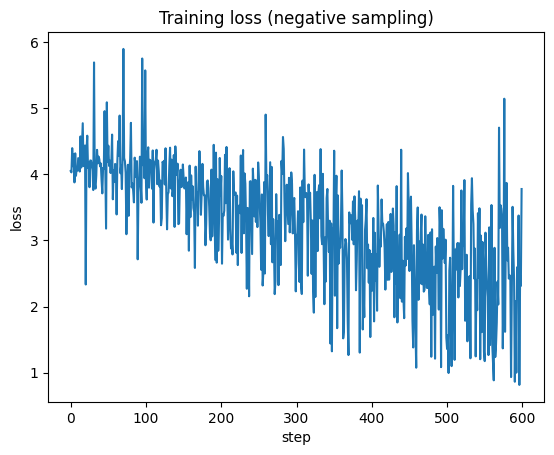

In [ ]:
plt.figure()
plt.plot(loss_hist)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Training loss (negative sampling)")
plt.show()

Now the evolution of the distances between pairs

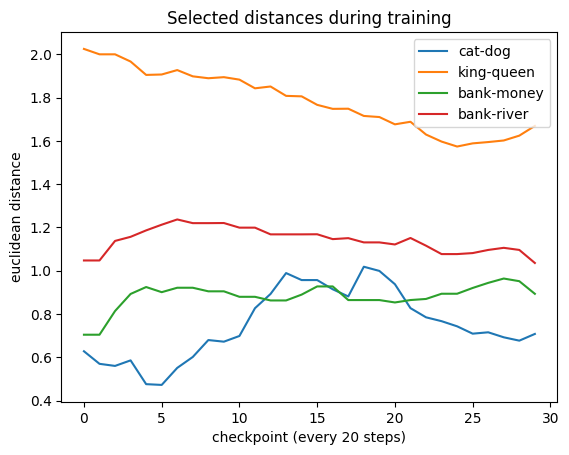

In [ ]:
if valid_tracks:
    plt.figure()
    for (a, b), vals in dist_history.items():
        plt.plot(vals, label=f"{a}-{b}")
    plt.xlabel("checkpoint (every 20 steps)")
    plt.ylabel("euclidean distance")
    plt.title("Selected distances during training")
    plt.legend()
    plt.show()

Finally the embedded 2D geometry of words (this is similar to the PCA reduction to 2 dimensions)

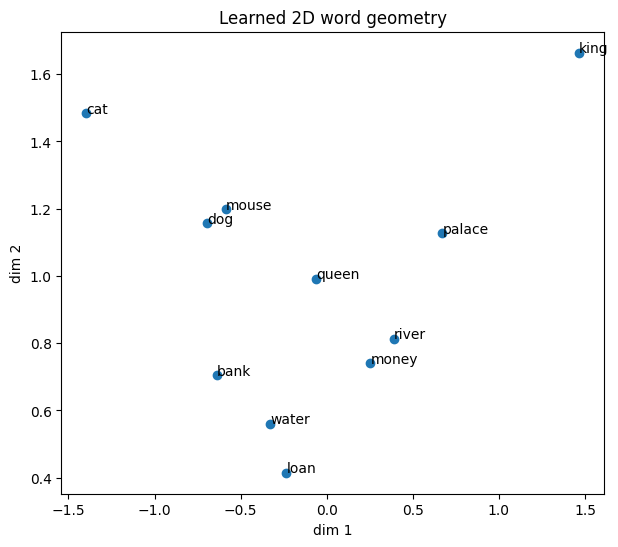

In [ ]:
emb = current_in_emb()
words_to_show = ["cat", "dog", "mouse", "king", "queen", "palace", "bank", "money", "river", "water", "loan"]
plot_embeddings_2d(emb, id2word, words_to_show, word2id)

And numerically we can obtain the nearest neighbors

In [ ]:
nearest_neighbors(emb, word2id, id2word, "cat", topn=5)
nearest_neighbors(emb, word2id, id2word, "bank", topn=5)


Nearest neighbors for 'cat':
          bank  cos=1.000
           ran  cos=0.998
           sat  cos=0.996
           dog  cos=0.977
         water  cos=0.974

Nearest neighbors for 'bank':
           cat  cos=1.000
           ran  cos=0.999
           sat  cos=0.994
           dog  cos=0.981
         water  cos=0.978


How would you interpret these results?